# RoBERTa - SST-5 Sentiment Classification

This project fine-tunes the pretrained `roberta-base` model for five-class sentiment classification on the Stanford Sentiment Treebank (SST-5). The notebook uses the dataset's provided training, validation, and test splits, standard Hugging Face `Trainer` fine-tuning, validation-based checkpoint selection, and detailed post-training analysis including class-level metrics, confusion analysis, ordinal sentiment error, confidence, and representative mistakes.

A separate masked-language-model demonstration shows a capability of pretrained RoBERTa outside the downstream sentiment classifier.

## 1. Import Required Libraries

Import the libraries required for dataset loading, tokenization, RoBERTa fine-tuning, evaluation, visualization, and reproducibility.

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import load_dataset
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    pipeline
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch Version: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


## 2. Load the SST-5 Dataset

Load the provided SST-5 training, validation, and test splits. The existing validation split is retained rather than creating another split.

In [2]:
dataset = load_dataset("SetFit/sst5")

print(dataset)

for split_name in dataset.keys():
    print(f"{split_name}: {len(dataset[split_name])} samples")

class_names = [
    "Very Negative",
    "Negative",
    "Neutral",
    "Positive",
    "Very Positive"
]

print("Classes:", class_names)

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.32M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/343k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 8544
    })
    validation: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1101
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 2210
    })
})
train: 8544 samples
validation: 1101 samples
test: 2210 samples
Classes: ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']


## 3. Explore the Dataset

Inspect the class distribution and representative examples to understand the five ordered sentiment levels.

Training Samples: 8544
Validation Samples: 1101
Test Samples: 2210

Training Distribution: [1092 2218 1624 2322 1288]
Validation Distribution: [139 289 229 279 165]
Test Distribution: [279 633 389 510 399]


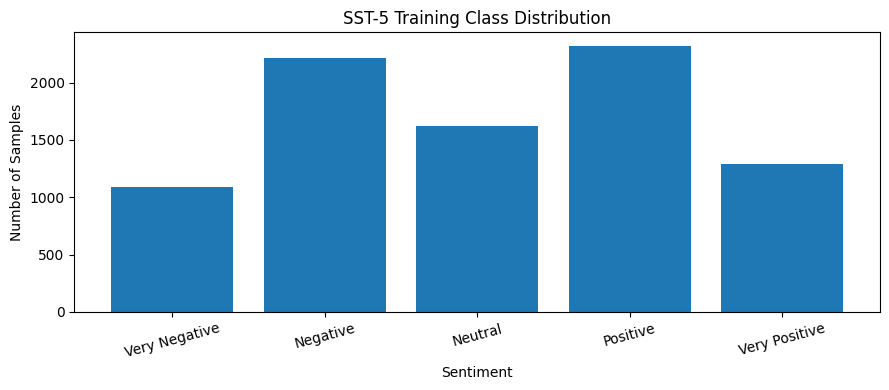

Class: Very Negative
final verdict : you 've seen it all before .
lacks the inspiration of the original and has a bloated plot that stretches the running time about 10 minutes past a child 's interest and an adult 's patience .

Class: Negative
apparently reassembled from the cutting-room floor of any given daytime soap .
they presume their audience wo n't sit still for a sociology lesson , however entertainingly presented , so they trot out the conventional science-fiction elements of bug-eyed monsters and futuristic women in skimpy clothes .

Class: Neutral
the entire movie is filled with deja vu moments .
um , no. .

Class: Positive
this is a visually stunning rumination on love , memory , history and the war between art and commerce .
jonathan parker 's bartleby should have been the be-all-end-all of the modern-office anomie films .

Class: Very Positive
a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
béart and berling are bot

In [3]:
train_labels = np.array(
    dataset["train"]["label"],
    dtype=np.int64
)

val_labels = np.array(
    dataset["validation"]["label"],
    dtype=np.int64
)

test_labels = np.array(
    dataset["test"]["label"],
    dtype=np.int64
)

train_counts = np.bincount(
    train_labels,
    minlength=len(class_names)
)

val_counts = np.bincount(
    val_labels,
    minlength=len(class_names)
)

test_counts = np.bincount(
    test_labels,
    minlength=len(class_names)
)

print("Training Samples:", len(dataset["train"]))
print("Validation Samples:", len(dataset["validation"]))
print("Test Samples:", len(dataset["test"]))

print("\nTraining Distribution:", train_counts)
print("Validation Distribution:", val_counts)
print("Test Distribution:", test_counts)

plt.figure(figsize=(9, 4))
plt.bar(class_names, train_counts)
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("SST-5 Training Class Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

for class_id, class_name in enumerate(class_names):
    matches = [
        index
        for index, label in enumerate(
            dataset["train"]["label"]
        )
        if label == class_id
    ]

    print("=" * 90)
    print("Class:", class_name)

    for index in matches[:2]:
        print(dataset["train"][index]["text"])

    print()

## 4. Load the RoBERTa Tokenizer

Use the pretrained RoBERTa tokenizer so text is represented using the same subword vocabulary used during pretraining.

In [4]:
model_name = "roberta-base"
max_length = 128

tokenizer = RobertaTokenizerFast.from_pretrained(
    model_name
)

print("Model:", model_name)
print("Vocabulary Size:", tokenizer.vocab_size)
print("Maximum Sequence Length:", max_length)

sample = tokenizer(
    dataset["train"][0]["text"],
    truncation=True,
    padding="max_length",
    max_length=max_length
)

print("Sample Token Count:", len(sample["input_ids"]))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: roberta-base
Vocabulary Size: 50265
Maximum Sequence Length: 128
Sample Token Count: 128


## 5. Tokenize the Dataset

Tokenize each dataset split with truncation and fixed-length padding for a simple, stable baseline.

In [5]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

tokenized_train = dataset["train"].map(
    tokenize_batch,
    batched=True
)

tokenized_validation = dataset["validation"].map(
    tokenize_batch,
    batched=True
)

tokenized_test = dataset["test"].map(
    tokenize_batch,
    batched=True
)

print(tokenized_train)
print(tokenized_validation)
print(tokenized_test)

Map:   0%|          | 0/8544 [00:00<?, ? examples/s]

Map:   0%|          | 0/1101 [00:00<?, ? examples/s]

Map:   0%|          | 0/2210 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'attention_mask'],
    num_rows: 8544
})
Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'attention_mask'],
    num_rows: 1101
})
Dataset({
    features: ['text', 'label', 'label_text', 'input_ids', 'attention_mask'],
    num_rows: 2210
})


## 6. Build the RoBERTa Classifier

Load pretrained RoBERTa with a new five-class sequence-classification head.

In [6]:
model = RobertaForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(class_names),
    id2label={
        i: name
        for i, name in enumerate(class_names)
    },
    label2id={
        name: i
        for i, name in enumerate(class_names)
    }
)

print("Model:", model_name)
print("Number of Labels:", model.config.num_labels)
print(
    "Trainable Parameters:",
    f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Number of Labels: 5
Trainable Parameters: 124,649,477


## 7. Define Evaluation Metrics

Track accuracy, macro and weighted precision, recall, and F1-score for validation and final evaluation.

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1
    }

## 8. Configure Fine-Tuning

Configure a standard Hugging Face Trainer baseline using a conservative learning rate, weight decay, and validation-based checkpoint selection.

In [8]:
batch_size = 32
learning_rate = 2e-5
num_epochs = 10

training_args = TrainingArguments(
    output_dir="./roberta_sst5_results",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=2
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Batch Size:", batch_size)
print("Learning Rate:", learning_rate)
print("Maximum Epochs:", num_epochs)
print("Metric for Best Checkpoint: Validation Accuracy")

Batch Size: 32
Learning Rate: 2e-05
Maximum Epochs: 10
Metric for Best Checkpoint: Validation Accuracy


## 9. Fine-Tune RoBERTa

Train on the provided training split and evaluate on the provided validation split after every epoch. The best validation checkpoint is restored automatically.

In [9]:
train_result = trainer.train()

print("Training completed.")
print("Training Loss:", train_result.training_loss)
print("Best Checkpoint:", trainer.state.best_model_checkpoint)

if trainer.state.best_metric is not None:
    print(
        f"Best Validation Accuracy: "
        f"{trainer.state.best_metric:.4f}"
    )

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.573801,1.576675,0.262489,0.052498,0.200000,0.083165,0.068900,0.262489,0.109150
2,1.571422,1.578918,0.253406,0.050681,0.200000,0.080870,0.064215,0.253406,0.102464
3,1.566746,1.548182,0.302452,0.264410,0.235472,0.169641,0.304775,0.302452,0.215653
4,1.550385,1.525994,0.317893,0.229740,0.249193,0.185686,0.270568,0.317893,0.234055
5,1.525611,1.526637,0.322434,0.366543,0.259920,0.207632,0.383041,0.322434,0.247949
6,1.503926,1.505635,0.333333,0.319421,0.278226,0.241331,0.341707,0.333333,0.276307
7,1.482257,1.485126,0.343324,0.325128,0.283213,0.245401,0.346147,0.343324,0.284225
8,1.454323,1.474955,0.350590,0.361182,0.293969,0.263371,0.361481,0.350590,0.298714
9,1.433852,1.479380,0.351499,0.335335,0.301330,0.275770,0.343474,0.351499,0.307859
10,1.414211,1.490405,0.335150,0.317082,0.297085,0.275955,0.324342,0.335150,0.301145


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed.
Training Loss: 1.5076534199803957
Best Checkpoint: ./roberta_sst5_results/checkpoint-2403
Best Validation Accuracy: 0.3515


## 10. Training Curves

Visualize training and validation loss and validation performance to assess convergence and overfitting.

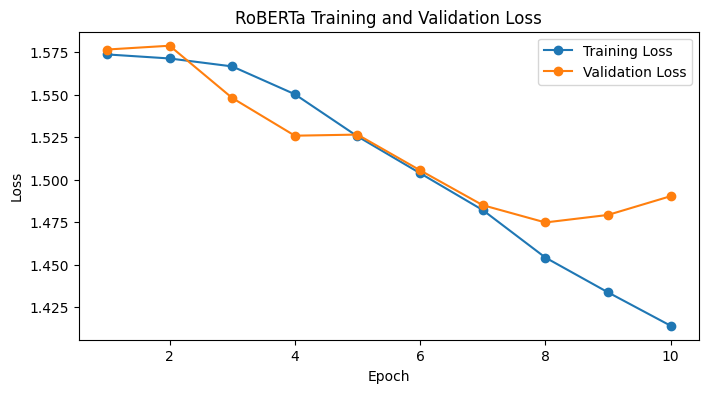

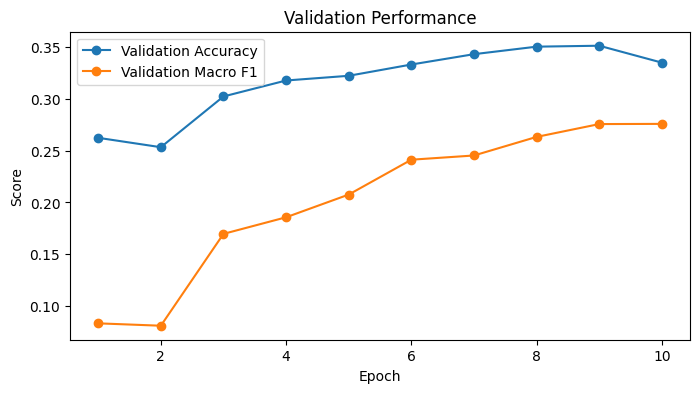

Best Epoch: 9
Best Validation Accuracy: 0.3515
Validation Macro F1 at Best Epoch: 0.2758


In [10]:
history = pd.DataFrame(
    trainer.state.log_history
)

train_history = history[
    history["loss"].notna()
].copy()

eval_history = history[
    history["eval_loss"].notna()
].copy()

plt.figure(figsize=(8, 4))
plt.plot(
    train_history["epoch"],
    train_history["loss"],
    marker="o",
    label="Training Loss"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_loss"],
    marker="o",
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RoBERTa Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(
    eval_history["epoch"],
    eval_history["eval_accuracy"],
    marker="o",
    label="Validation Accuracy"
)
plt.plot(
    eval_history["epoch"],
    eval_history["eval_macro_f1"],
    marker="o",
    label="Validation Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Performance")
plt.legend()
plt.show()

best_row = eval_history.loc[
    eval_history["eval_accuracy"].idxmax()
]

print(
    "Best Epoch:",
    int(best_row["epoch"])
)

print(
    f"Best Validation Accuracy: "
    f"{best_row['eval_accuracy']:.4f}"
)

print(
    f"Validation Macro F1 at Best Epoch: "
    f"{best_row['eval_macro_f1']:.4f}"
)

## 11. Final Test Evaluation

Evaluate the restored best checkpoint exactly once on the untouched test split.

In [11]:
test_output = trainer.predict(
    tokenized_test
)

test_predictions = np.argmax(
    test_output.predictions,
    axis=-1
)

test_labels_final = np.array(
    test_output.label_ids
)

test_accuracy = accuracy_score(
    test_labels_final,
    test_predictions
)

test_macro_precision, test_macro_recall, test_macro_f1, _ = (
    precision_recall_fscore_support(
        test_labels_final,
        test_predictions,
        average="macro",
        zero_division=0
    )
)

test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = (
    precision_recall_fscore_support(
        test_labels_final,
        test_predictions,
        average="weighted",
        zero_division=0
    )
)

print(f"Test Loss: {test_output.metrics.get('test_loss', float('nan')):.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro Precision: {test_macro_precision:.4f}")
print(f"Test Macro Recall: {test_macro_recall:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Test Weighted F1: {test_weighted_f1:.4f}")

Test Loss: 1.4919
Test Accuracy: 0.3498
Test Macro Precision: 0.3655
Test Macro Recall: 0.2980
Test Macro F1: 0.2773
Test Weighted F1: 0.3143


## 12. Classification Report and Confusion Matrix

Inspect class-level performance and identify the directions in which the sentiment classes are confused.

               precision    recall  f1-score   support

Very Negative     0.3125    0.0179    0.0339       279
     Negative     0.4073    0.5134    0.4542       633
      Neutral     0.3644    0.1105    0.1696       389
     Positive     0.2753    0.5549    0.3680       510
Very Positive     0.4680    0.2932    0.3606       399

     accuracy                         0.3498      2210
    macro avg     0.3655    0.2980    0.2773      2210
 weighted avg     0.3683    0.3498    0.3143      2210



,Very Negative,Negative,Neutral,Positive,Very Positive
Very Negative,5,131,18,109,16
Negative,4,325,31,253,20
Neutral,3,155,43,173,15
Positive,3,122,20,283,82
Very Positive,1,65,6,210,117


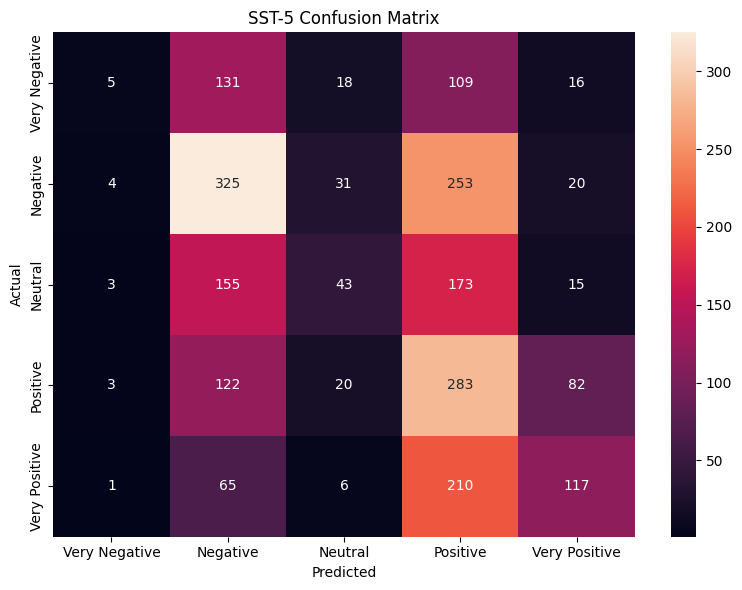

In [12]:
print(
    classification_report(
        test_labels_final,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

cm = confusion_matrix(
    test_labels_final,
    test_predictions
)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SST-5 Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Ordinal Sentiment Error Analysis

Use the natural ordering of SST-5 sentiment labels to measure how far predictions are from the true sentiment level.

Mean Absolute Sentiment Error: 1.0403
Exact Sentiment Accuracy: 0.3498
Within One Sentiment Level: 0.7145


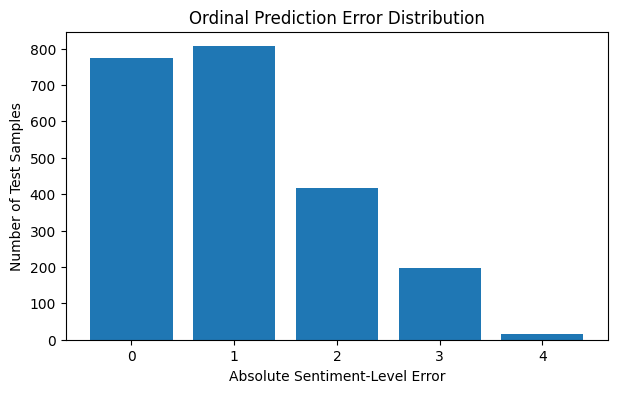

In [13]:
absolute_errors = np.abs(
    test_labels_final - test_predictions
)

mean_absolute_sentiment_error = np.mean(
    absolute_errors
)

exact_accuracy = np.mean(
    absolute_errors == 0
)

within_one_level = np.mean(
    absolute_errors <= 1
)

print(
    f"Mean Absolute Sentiment Error: "
    f"{mean_absolute_sentiment_error:.4f}"
)

print(
    f"Exact Sentiment Accuracy: "
    f"{exact_accuracy:.4f}"
)

print(
    f"Within One Sentiment Level: "
    f"{within_one_level:.4f}"
)

error_counts = (
    pd.Series(absolute_errors)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7, 4))
plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)
plt.xlabel("Absolute Sentiment-Level Error")
plt.ylabel("Number of Test Samples")
plt.title("Ordinal Prediction Error Distribution")
plt.show()

## 14. Confidence Analysis

Compare prediction confidence for correct and incorrect examples.

Mean Confidence - Correct: 0.4087
Mean Confidence - Incorrect: 0.3823


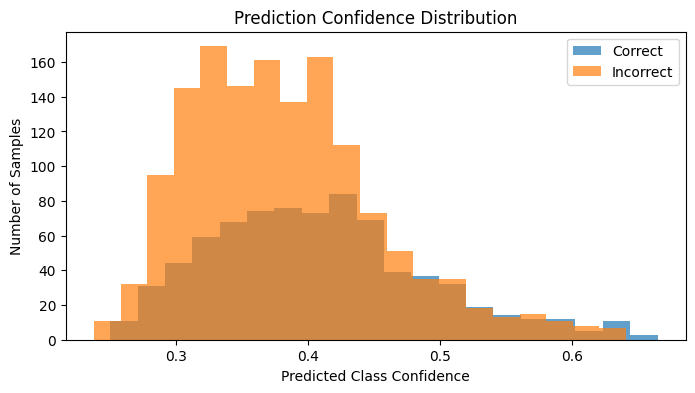

In [14]:
probabilities = torch.softmax(
    torch.tensor(
        test_output.predictions
    ),
    dim=-1
).numpy()

predicted_confidence = probabilities[
    np.arange(len(test_predictions)),
    test_predictions
]

correct_mask = (
    test_predictions == test_labels_final
)

print(
    f"Mean Confidence - Correct: "
    f"{predicted_confidence[correct_mask].mean():.4f}"
)

if np.any(~correct_mask):
    print(
        f"Mean Confidence - Incorrect: "
        f"{predicted_confidence[~correct_mask].mean():.4f}"
    )

plt.figure(figsize=(8, 4))
plt.hist(
    predicted_confidence[correct_mask],
    bins=20,
    alpha=0.7,
    label="Correct"
)

if np.any(~correct_mask):
    plt.hist(
        predicted_confidence[~correct_mask],
        bins=20,
        alpha=0.7,
        label="Incorrect"
    )

plt.xlabel("Predicted Class Confidence")
plt.ylabel("Number of Samples")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()

## 15. Representative Error Analysis

Inspect representative mistakes and their strongest alternative predictions.

In [15]:
misclassified_indices = np.where(
    test_predictions != test_labels_final
)[0]

print(
    "Misclassified Test Samples:",
    len(misclassified_indices)
)

for index in misclassified_indices[:10]:
    probabilities_row = probabilities[index]

    top_indices = np.argsort(
        probabilities_row
    )[-3:][::-1]

    print("=" * 100)
    print(
        "Text:",
        dataset["test"][int(index)]["text"]
    )
    print(
        "True Label:",
        class_names[test_labels_final[index]]
    )
    print(
        "Predicted Label:",
        class_names[test_predictions[index]]
    )
    print("Top Predictions:")

    for class_id in top_indices:
        print(
            f"  {class_names[class_id]}: "
            f"{probabilities_row[class_id]:.4f}"
        )

Misclassified Test Samples: 1437
Text: a gob of drivel so sickly sweet , even the eager consumers of moore 's pasteurized ditties will retch it up like rancid crème brûlée .
True Label: Very Negative
Predicted Label: Positive
Top Predictions:
  Positive: 0.3233
  Negative: 0.2229
  Very Positive: 0.1591
Text: so relentlessly wholesome it made me want to swipe something .
True Label: Neutral
Predicted Label: Negative
Top Predictions:
  Negative: 0.5210
  Neutral: 0.1881
  Very Negative: 0.1658
Text: gangs of new york is an unapologetic mess , whose only saving grace is that it ends by blowing just about everything up .
True Label: Very Negative
Predicted Label: Positive
Top Predictions:
  Positive: 0.3364
  Negative: 0.2380
  Neutral: 0.1714
Text: we never really feel involved with the story , as all of its ideas remain just that : abstract ideas .
True Label: Very Negative
Predicted Label: Positive
Top Predictions:
  Positive: 0.3729
  Very Positive: 0.2333
  Negative: 0.1668
Text: thi

## 16. Interactive Sentiment Prediction

Use the fine-tuned RoBERTa classifier on custom text.

In [16]:
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_length
    )

    device = next(model.parameters()).device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    ).cpu().numpy()[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    print("Text:", text)
    print(
        "Prediction:",
        class_names[predicted_class]
    )
    print(
        "Confidence:",
        f"{probabilities[predicted_class]:.4f}"
    )

    print("\nClass Probabilities:")

    for class_name, probability in zip(
        class_names,
        probabilities
    ):
        print(
            f"{class_name:<15}"
            f"{probability:.4f}"
        )

examples = [
    "This is the worst thing ever.",
    "It was okay, nothing special.",
    "I liked it quite a bit.",
    "Absolutely fantastic experience."
]

for example in examples:
    predict_sentiment(example)
    print("=" * 70)

Text: This is the worst thing ever.
Prediction: Positive
Confidence: 0.3086

Class Probabilities:
Very Negative  0.1196
Negative       0.2184
Neutral        0.1959
Positive       0.3086
Very Positive  0.1575
Text: It was okay, nothing special.
Prediction: Negative
Confidence: 0.4946

Class Probabilities:
Very Negative  0.1812
Negative       0.4946
Neutral        0.2405
Positive       0.0694
Very Positive  0.0144
Text: I liked it quite a bit.
Prediction: Negative
Confidence: 0.2834

Class Probabilities:
Very Negative  0.1211
Negative       0.2834
Neutral        0.2749
Positive       0.2422
Very Positive  0.0785
Text: Absolutely fantastic experience.
Prediction: Positive
Confidence: 0.4064

Class Probabilities:
Very Negative  0.0425
Negative       0.0854
Neutral        0.1022
Positive       0.4064
Very Positive  0.3636


## 17. RoBERTa Masked Language Modelling Demonstration

Use pretrained RoBERTa separately as a masked-language model to demonstrate its pretrained language understanding capability.

In [17]:
fill_mask = pipeline(
    "fill-mask",
    model="roberta-base",
    device=0 if torch.cuda.is_available() else -1
)

def suggest_words(text, top_k=5):
    if "<mask>" not in text:
        print("Please include <mask> in your sentence.")
        return

    results = fill_mask(
        text,
        top_k=top_k
    )

    print("Input:", text)
    print("Suggestions:")

    for result in results:
        word = result["token_str"].strip()
        score = result["score"]

        print(
            f"{word:<20}"
            f"{score:.4f}"
        )

suggest_words(
    "The movie was <mask>."
)

suggest_words(
    "This experience felt <mask> and strange."
)

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Input: The movie was <mask>.
Suggestions:
good                0.1075
awful               0.0763
great               0.0714
terrible            0.0682
released            0.0271
Input: This experience felt <mask> and strange.
Suggestions:
foreign             0.1090
strange             0.0694
unfamiliar          0.0529
surreal             0.0513
unexpected          0.0502


## 18. Key Findings



## 19. Conclusion

